# xsim-chip: 3D defect inspection quick start

This Colab notebook creates a small labelled semiconductor-package volume, injects controlled defects, and generates a material-aware inspection report. Root-cause entries are hypotheses for screening, not causal proof.

This is the standalone supplied-label example. For projections → independent slice reconstructions → reconstructed 3D volume → this same inspector, run [Notebook 04 in Colab](https://colab.research.google.com/github/yuweimin2077-hub/xsim-chip/blob/main/notebooks/04_slice_wise_3d_colab.ipynb).

## Saved outputs / 已保存的运行结果

The outputs below were freshly executed on **local Windows, CPU (NumPy/SciPy)**, Python 3.12.3; saved at **2026-10-03T02:39:14+00:00 (UTC)**. **These are not new Google Colab T4 measurements.**

下方已保存真实运行的文字、指标和图表，GitHub 中无需再次运行即可查看；来源是本地 CPU/GPU，并非本次 Colab T4 云端实测。

The Colab clone/install cell was skipped locally and intentionally has no output. A temporary local setup supplied the imports and inline plotting; only `/content` output paths were redirected to `outputs/notebook_output_capture/`. The experiment code shown below is unchanged and can still be run in Colab. Timings are fresh samples and may differ from the archived report.


In [ ]:
!git clone -q https://github.com/yuweimin2077-hub/xsim-chip.git
%cd xsim-chip
%pip install -q -e '.[demo]'

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from xsim_chip_analysis import Material, analyze_against_reference

reference = np.zeros((64, 64, 64), dtype=np.uint8)
reference[8:56, 8:56, 8:56] = Material.SILICON_DIOXIDE
reference[20:44, 20:44, 20:44] = Material.COPPER
reference[27:37, 27:37, 27:37] = Material.SAC305_SOLDER
candidate = reference.copy()
candidate[29:34, 29:34, 29:34] = Material.VACUUM  # solder void/open
candidate[38:42, 30:34, 30:34] = Material.SAC305_SOLDER  # solder bridge
report = analyze_against_reference(reference, candidate, voxel_size_um=4.0)
print(json.dumps(report['summary'], indent=2))

{
  "defect_count": 3,
  "critical": 2,
  "major": 1,
  "minor": 0
}


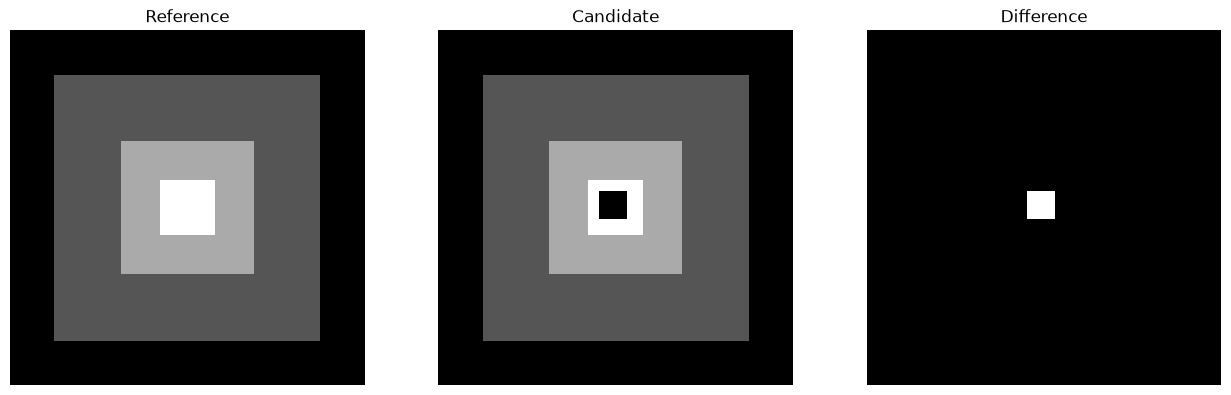

In [3]:
z = 31
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, image, title in zip(axes, [reference[z], candidate[z], reference[z] != candidate[z]], ['Reference', 'Candidate', 'Difference']):
    ax.imshow(image, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout();

In [4]:
report['defects']

[{'defect_id': 'D0001',
  'defect_kind': 'solder_void_or_open',
  'material': 'sac305_solder',
  'difference': 'missing',
  'voxel_count': 125,
  'volume_um3': 8000.0,
  'centroid_zyx_voxels': (31.0, 31.0, 31.0),
  'centroid_zyx_um': (124.0, 124.0, 124.0),
  'bounding_box_zyx': ((29, 34), (29, 34), (29, 34)),
  'severity': 'critical',
  'candidate_root_causes': ('trapped flux or outgassing during reflow',
   'insufficient solder volume or poor wetting',
   'reconstruction artefact near a high-attenuation interface')},
 {'defect_id': 'D0002',
  'defect_kind': 'solder_bridge',
  'material': 'sac305_solder',
  'difference': 'excess',
  'voxel_count': 64,
  'volume_um3': 4096.0,
  'centroid_zyx_voxels': (39.5, 31.5, 31.5),
  'centroid_zyx_um': (158.0, 126.0, 126.0),
  'bounding_box_zyx': ((38, 42), (30, 34), (30, 34)),
  'severity': 'critical',
  'candidate_root_causes': ('excess paste deposition',
   'component placement offset or solder collapse',
   'segmentation blooming around solder'